In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


import gym
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
from IPython.display import clear_output

class ActorCritic(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ActorCritic, self).__init__()
        self.out_dim = output_dim
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out_fc = nn.Linear(128, output_dim*2)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        out = self.out_fc(x)
        mean = out[:, :self.out_dim]
        log_std = torch.clamp(out[:, self.out_dim:], -20, 2) # Soft Actor-Critic建議數值
        std = torch.exp(log_std)
        return mean, std
    
ActorCriticModel = ActorCritic(input_dim=4, output_dim=2)
test_data = torch.randn(1, 4)
mean, std = ActorCriticModel(test_data)
print("Mean:", mean)
print("Std:", std)

Mean: tensor([[-0.1962, -0.0082]], grad_fn=<SliceBackward0>)
Std: tensor([[0.9650, 0.9867]], grad_fn=<ExpBackward0>)


In [2]:
class ActorCriticAgent:
    def __init__(self, state_dim, action_dim, gamma = 0.99, lr = 1e-5, device = device):
        self.state_dim, self.action_dim = state_dim, action_dim
        self.gamma = gamma
        self.model = ActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.rewards = []
        self.best_reward = -np.inf

    def make_action(self, state, _random = True):
        state = torch.FloatTensor(state).to(device)
        mean, std = self.model(state.unsqueeze(0))
        if _random:
            action = np.random.normal(mean.cpu().detach().numpy(), std.cpu().detach().numpy())
        else:
            action = mean.cpu().detach().numpy()
        return action

    def fit(self, env, episodes = 1000):
        for episode in range(episodes):
            state = env.reset()
            done = False
            total_reward = 0
            while not done:
                action = self.make_action(state)
                next_state, reward, done, _ = env.step(action)
                total_reward += reward
                state = next_state
            self.rewards.append(total_reward)
            if total_reward > self.best_reward:
                self.best_reward = total_reward
                torch.save(self.model.state_dict(), "best_model.pth")
            print("Total Reward: {Reward}, best: {Best}".format(Reward = total_reward, Best = self.best_reward))
            plt.figure(figsize = (12, 3))
            plt.plot(self.rewards, color = "blue")
            plt.grid(color = "gray", linestyle = "--", alpha = 0.5)
            plt.xlabel("Episode")
            plt.ylabel("Total Reward")
            plt.show()
            clear_output(wait = True)

In [3]:
class Anomaly_Score_ENV:
    def __init__(self, scores, labels, win_size=10):
        # 初始化環境
        self.scores = scores
        self.Labels = labels
        self.threshold = np.mean(scores)
        self.UB, self.LB = np.max(scores) + np.std(scores), np.min(scores) - np.std(scores)
        self.timesteps = len(scores)
        self.current_step = 0
        self.done = False

        # 滑動視窗大小
        self.win_size = win_size
        self.windows = list()
        self.labels = list()
        for i in range(win_size, len(scores)-win_size, win_size):
            self.windows.append(scores[i-win_size:i])
            self.labels.append(labels[i-win_size:i])
        self.windows = np.array(self.windows)
        self.labels = np.array(self.labels)

    def _get_state(self):
        states = list(self.windows[self.current_step]) + [float(self.threshold)]
        return np.array(states, dtype=np.float32)
    
    def step(self, action):
        state = self._get_state()
        reward = self._get_reward(action)
        self.current_step += 1
        if self.current_step >= len(self.windows) - 1: self.done = True
        next_states = self._get_state()
        return state, reward, self.done, next_states

    def reset(self):
        # 重置環境與重設閾值
        self.current_step = 0
        states = list(self.windows[self.current_step]) + [self.threshold]
        self.threshold = np.mean(self.scores)
        return states
    
    def _get_reward(self, action):
        # Action是一個整數，表示增加或減少閾值
        self.threshold += np.clip(action, self.LB, self.UB)

        # 計算當前狀態的獎勵，並且處理不平衡的問題
        window = self.windows[self.current_step]
        label = self.labels[self.current_step]
        true, false = np.sum(self.Labels == 1), np.sum(self.Labels == 0)
        true_weight = false/true
        
        tp = np.sum((window >= self.threshold) & (label == 1))
        fp = np.sum((window >= self.threshold) & (label == 0))
        fn = np.sum((window < self.threshold) & (label == 1))
        tn = np.sum((window < self.threshold) & (label == 0))
        Rt = (tp-fn)*true_weight + (tn-fp)

        return Rt

In [ ]:
array = np.random.randn(500)
IDX = np.random.randint(0, 500, 50)
array[IDX] = np.random.normal(10, 0.02, 50)
label = np.zeros(500)
label[IDX] = 1
env = Anomaly_Score_ENV(array, label, win_size=10)
ActorCriticAgent(state_dim=11, action_dim=1).fit(env, episodes=1000)

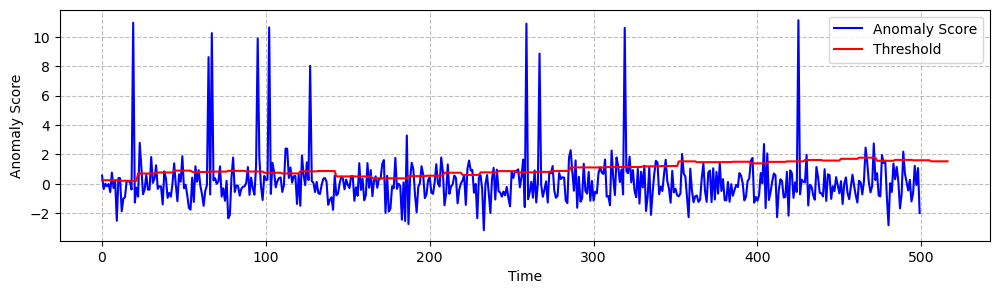

In [11]:
done = False
array = np.random.randn(500)
IDX = np.random.randint(0, 500, 10)
array[IDX] = np.random.randn(10) + 10
label = np.zeros(500)
label[IDX] = 1
Env = Anomaly_Score_ENV(array, label, win_size=10)
state = Env.reset()
threslold = Env.threshold
thetas = list()
while not done:
    action = ActorCriticAgent(state_dim=11, action_dim=1).make_action(state, _random=False)
    state, reward, done, next_state = Env.step(action)
    thetas += [float(Env.threshold)]*len(state)
plt.figure(figsize=(12, 3))
plt.plot(array, color = "blue", label = "Anomaly Score")
plt.plot(thetas, color = "red", label = "Threshold")
plt.grid(color = "gray", linestyle = "--", alpha = 0.5)
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()
    